# Examples for Geodesics on Toy Datasets

In [41]:
# libraries 
import torch 
import numpy as np 
from matplotlib import pyplot as plt 
import os

In [42]:
# local imports
from experiments_toy_datasets.manifolds.score_metrics import *
from experiments_toy_datasets.discrete_geodesics import *
from experiments_toy_datasets.graph_based_initialization import *
from experiments_toy_datasets.toy_datasets_utils import *
from experiments_toy_datasets.plotting import *
from experiments_toy_datasets.sample_pairs import *

(<Figure size 1300x650 with 2 Axes>,
 array([<AxesSubplot:title={'center':'1-sphere'}>,
        <AxesSubplot:title={'center':'s-curve'}>], dtype=object))

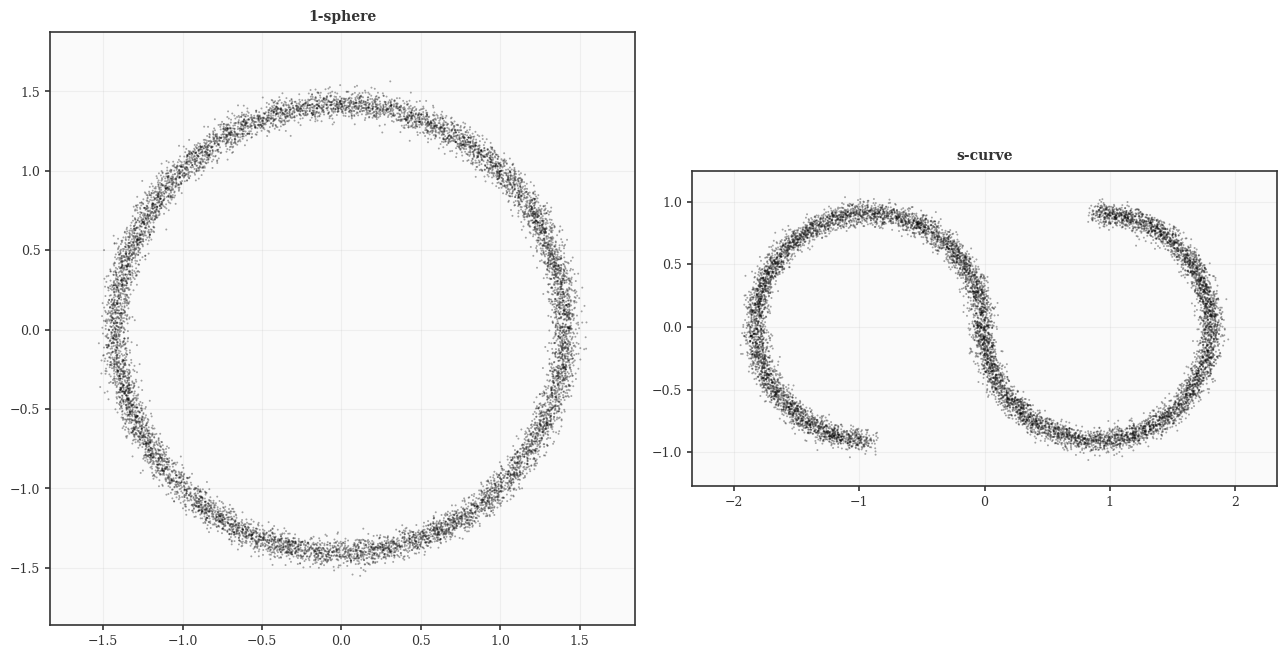

In [13]:
# plot the datasets 
datasets = ['1-sphere', 's-curve']
plot_grid(datasets, kind='data')

## Geodesics on S-Curve and Circle

In [40]:
data_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/toy_data' 
device = 'gpu' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [ ]:
n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.nelement())
    X_shuffled = X.view(-1)[idx].view(X.size())
    reference_points = X_shuffled[:2000]

    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # define the metric, e.g. PER, SAI, AZE, INVP or ours (G_lam)
    # for example, INVP, normalized to 1 on the manifold, 1000 off manifold
    manifold, _ = build_INVP(deriv=deriv, reference_points=reference_points, target_min=1.0, target_max=1000, normalize=True)

    # sample pairs from the datasets
    pairs = get_pairs(ds_name, meta, n_pairs = 5)

    # optimize geodesics (linear initialization for now)

    for pair_idx, (z0_np, z1_np) in enumerate(pairs):
            z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
            z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

            # lerp init
            t = torch.linspace(0, 1, n_points)[:, None]
            z_init = (1 - t) * z0[None, :] + t * z1[None, :]
            # run optimization loop 
            tag = f'{ds_name}/INVP/p{pair_idx}'
            curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

            # save geodesics to disk for plotting purposes 
            fname = f'{ds_name}_INVP_p{pair_idx}.pt'
            torch.save({
                'curve':         curve,
                'z0':            torch.tensor(z0_np),
                'z1':            torch.tensor(z1_np),
                'metric':        mname,
                'dataset':       ds_name,
                'pair_idx':      pair_idx,
            }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/INVP/p0, ep=0, loss=3715.533447265625
1-sphere/INVP/p0, ep=499, loss=323.8179931640625
1-sphere/INVP/p0, ep=999, loss=78.53365325927734
1-sphere/INVP/p0, ep=1499, loss=42.092918395996094


KeyboardInterrupt: 

In [ ]:
# plot geodesics 


